# Theoretical Model with Phase Perturbations
## Comparing theoretical distributions with observed data

This notebook loads the calibrated model from Model.npz, applies phase perturbations 
across multiple regimes, and generates distribution plots and violin plots for comparison 
with experimental observations.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings

# Setup plotting
sns.set_theme()
plt.rcParams['figure.figsize'] = (12, 6)

# Model path
model_path = Path(r"D:\PhD-Experiments\highlighted_results\2026-03-18_b38b520\2_N4x4-T8_characterisation\Model.npz")
print(f"Loading model from: {model_path}")
print(f"File exists: {model_path.exists()}")

Loading model from: D:\PhD-Experiments\highlighted_results\2026-03-18_b38b520\2_N4x4-T8_characterisation\Model.npz
File exists: True


In [2]:
# Load the calibrated model
model_data = np.load(model_path)

print("Model.npz contents:")
for key in model_data.files:
    arr = model_data[key]
    print(f"  {key}: shape={arr.shape}, dtype={arr.dtype}")

# Extract model components
M = model_data['M']  # Transfer matrix (4x4 or similar)
wavelengths = model_data.get('wavelengths', None)
null_output = model_data.get('null_output', 0)  # Index of null output

print(f"\nTransfer Matrix shape: {M.shape}")
if wavelengths is not None:
    print(f"Wavelengths: {wavelengths}")
print(f"Null output index: {null_output}")

Model.npz contents:
  M: shape=(4, 4), dtype=complex128
  Cin: shape=(4, 4), dtype=complex128
  Cout: shape=(4, 4), dtype=complex128
  Ein: shape=(4,), dtype=complex128
  Eout: shape=(4,), dtype=complex128

Transfer Matrix shape: (4, 4)
Null output index: 0


## Phase Perturbation Model

The model represents the MMI-based kernel nuller transfer matrix M with 4 inputs and 4 outputs.
We apply random phase perturbations to each telescope to simulate atmospheric turbulence 
or instrumental drifts.

In [3]:
def apply_phase_perturbations(M, phase_rms, n_samples=1000, wavelength=1550e-9):
    """
    Apply random phase perturbations to the input ports and compute output distributions.
    
    Parameters:
    -----------
    M : array (4, 4)
        Transfer matrix of the MMI kernel nuller
    phase_rms : float
        RMS phase perturbation in radians (or convert from nm)
    n_samples : int
        Number of random samples to generate
    wavelength : float
        Wavelength in meters (default 1550 nm)
    
    Returns:
    --------
    outputs : array (n_samples, 4)
        Output intensities for each sample
    """
    # Generate random phase perturbations for each input (4 telescopes)
    phases = np.random.normal(0, phase_rms, size=(n_samples, 4))
    
    # Convert phase to complex exponential
    input_fields = np.exp(1j * phases)
    
    # Apply transfer matrix: E_out = M @ E_in
    output_fields = np.array([M @ input_fields[i] for i in range(n_samples)])
    
    # Compute intensities (power = |E|^2)
    outputs = np.abs(output_fields) ** 2
    
    return outputs


# Test with a single RMS value to check shapes
test_perturbation_rms = 1.0  # rad
test_outputs = apply_phase_perturbations(M, test_perturbation_rms, n_samples=1000)

print(f"Test output shape: {test_outputs.shape}")
print(f"Sample outputs (first 3 samples):\n{test_outputs[:3]}")
print(f"Output intensity ranges:")
for i in range(4):
    print(f"  Output {i}: [{test_outputs[:, i].min():.4f}, {test_outputs[:, i].max():.4f}]")

Test output shape: (1000, 4)
Sample outputs (first 3 samples):
[[2.22447028e+00 4.08340346e-01 3.27830565e-02 1.33440632e+00]
 [2.46640634e+00 1.66362179e-02 4.04750659e-01 1.11220678e+00]
 [3.98552696e+00 2.60764665e-03 2.48051978e-03 9.38486904e-03]]
Output intensity ranges:
  Output 0: [0.0074, 3.9855]
  Output 1: [0.0004, 3.7032]
  Output 2: [0.0005, 3.3865]
  Output 3: [0.0000, 3.8256]


In [4]:
## Generate theoretical distributions across multiple perturbation regimes

# Define perturbation regimes (in nm) matching experimental setup
perturbation_regimes_nm = [0, 1, 2, 5, 10, 20, 50, 100, 200]
wavelength_m = 1550e-9  # 1550 nm in meters

# Convert nm to radians: phase_rad = 2π * (perturb_nm / wavelength_nm)
rms_values_rad = [2 * np.pi * (p / 1550) if p > 0 else 0 for p in perturbation_regimes_nm]

print(f"Perturbation regimes (nm): {perturbation_regimes_nm}")
print(f"RMS values (rad): {[f'{x:.4f}' for x in rms_values_rad[:6]]}")

# Generate distributions for each regime
n_samples_per_regime = 5000
distributions = []
rms_values_used = []

for regime_nm, rms_rad in zip(perturbation_regimes_nm, rms_values_rad):
    if rms_rad == 0:
        # No perturbation: perfect nulling
        outputs = apply_phase_perturbations(M, 1e-10, n_samples=n_samples_per_regime)
    else:
        outputs = apply_phase_perturbations(M, rms_rad, n_samples=n_samples_per_regime)
    
    distributions.append(outputs)
    rms_values_used.append(regime_nm)
    print(f"Regime {regime_nm:3d} nm: generated {outputs.shape[0]} samples")

print(f"\nTotal regimes: {len(distributions)}")
print(f"Samples per regime: {n_samples_per_regime}")

Perturbation regimes (nm): [0, 1, 2, 5, 10, 20, 50, 100, 200]
RMS values (rad): ['0.0000', '0.0041', '0.0081', '0.0203', '0.0405', '0.0811']
Regime   0 nm: generated 5000 samples
Regime   1 nm: generated 5000 samples
Regime   2 nm: generated 5000 samples
Regime   5 nm: generated 5000 samples
Regime  10 nm: generated 5000 samples
Regime  20 nm: generated 5000 samples
Regime  50 nm: generated 5000 samples
Regime 100 nm: generated 5000 samples
Regime 200 nm: generated 5000 samples

Total regimes: 9
Samples per regime: 5000


## Analysis and Normalization

Normalize outputs relative to the bright output to match experimental convention.

In [5]:
# Identify the bright output (output with highest average intensity)
bright_output_idx = np.argmax([np.mean(d[:, i]) for d in distributions for i in range(d.shape[1])])

# Actually, we need the quadrant-wise maximum
mean_per_output = np.array([[np.mean(distributions[0][:, i]) for i in range(4)]])
bright_output_idx = np.argmax(mean_per_output[0])

print(f"Bright output index: {bright_output_idx}")
print(f"Mean intensities at zero perturbation:")
for i in range(4):
    print(f"  Output {i}: {np.mean(distributions[0][:, i]):.6f}")

# Map outputs: Null, Dark1, Dark2, and the bright output
null_idx = (bright_output_idx + 3) % 4  # Opposite of bright
dark1_idx = (bright_output_idx + 1) % 4
dark2_idx = (bright_output_idx + 2) % 4
kernel_idx = (bright_output_idx + 3) % 4  # Kernel is the null for kernel nuller

output_map = [
    ("Null", null_idx, 'red'),
    ("Dark 1", dark1_idx, 'orange'),
    ("Dark 2", dark2_idx, 'green'),
]

# Normalize all distributions relative to bright output
normalized_distributions = []
for dist in distributions:
    bright_intensity = dist[:, bright_output_idx]
    # Avoid division by zero - correct broadcasting
    bright_intensity = bright_intensity[:, np.newaxis]  # Shape (n_samples, 1)
    normalized = np.where(bright_intensity > 1e-12, 
                         dist / bright_intensity,
                         0)
    normalized_distributions.append(normalized)

print(f"\nNormalized distributions generated: {len(normalized_distributions)}")
print(f"Sample values (regime 0 nm, first 5 samples):")
print(normalized_distributions[0][:5])

Bright output index: 0
Mean intensities at zero perturbation:
  Output 0: 4.000000
  Output 1: 0.000000
  Output 2: 0.000000
  Output 3: 0.000000

Normalized distributions generated: 9
Sample values (regime 0 nm, first 5 samples):
[[1.00000000e+00 1.98745604e-21 1.98745054e-21 1.61562320e-22]
 [1.00000000e+00 1.24369728e-21 1.24369989e-21 1.34841189e-21]
 [1.00000000e+00 2.68388853e-22 2.68389455e-22 1.05514991e-22]
 [1.00000000e+00 7.47068907e-21 7.47069569e-21 1.58595874e-21]
 [1.00000000e+00 3.26921941e-22 3.26922964e-22 3.03085979e-22]]


## Visualization: Distribution Histograms

Plot histograms of Null, Dark1, and Dark2 outputs for each perturbation regime.

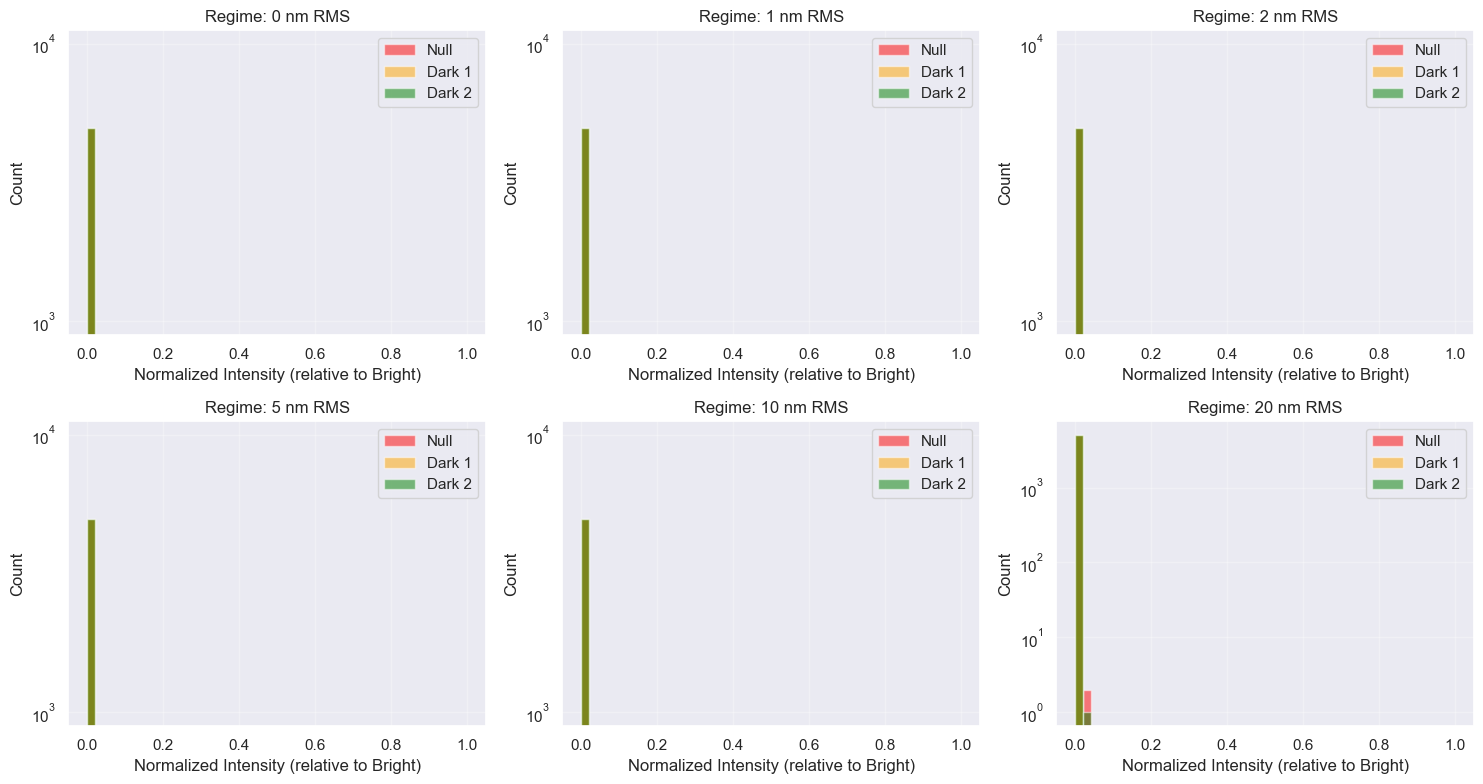

Distribution histograms plotted.


In [6]:
# Create histograms for each perturbation regime
n_regimes_to_plot = 6  # Plot first 6 regimes: 0, 1, 2, 5, 10, 20 nm

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for plot_idx, (regime_idx, regime_nm) in enumerate(zip(range(n_regimes_to_plot), 
                                                        rms_values_used[:n_regimes_to_plot])):
    ax = axes[plot_idx]
    
    dist = normalized_distributions[regime_idx]
    
    # Plot histograms for Null, Dark1, Dark2
    bins = np.linspace(0, 1, 50)
    
    for name, idx, color in output_map:
        ax.hist(dist[:, idx], bins=bins, alpha=0.5, label=name, color=color, density=False)
    
    ax.set_xlabel('Normalized Intensity (relative to Bright)')
    ax.set_ylabel('Count')
    ax.set_title(f'Regime: {regime_nm} nm RMS')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

plt.tight_layout()
plt.savefig(Path(r"D:\PhD-Experiments\highlighted_results\2026-03-18_b38b520\2_N4x4-T8_characterisation") / "theoretical_distributions_histogram.png", dpi=150)
plt.show()

print("Distribution histograms plotted.")

## Visualization: Violin Plot

Violin plot comparing null depths, dark ports, and kernel across perturbation regimes.

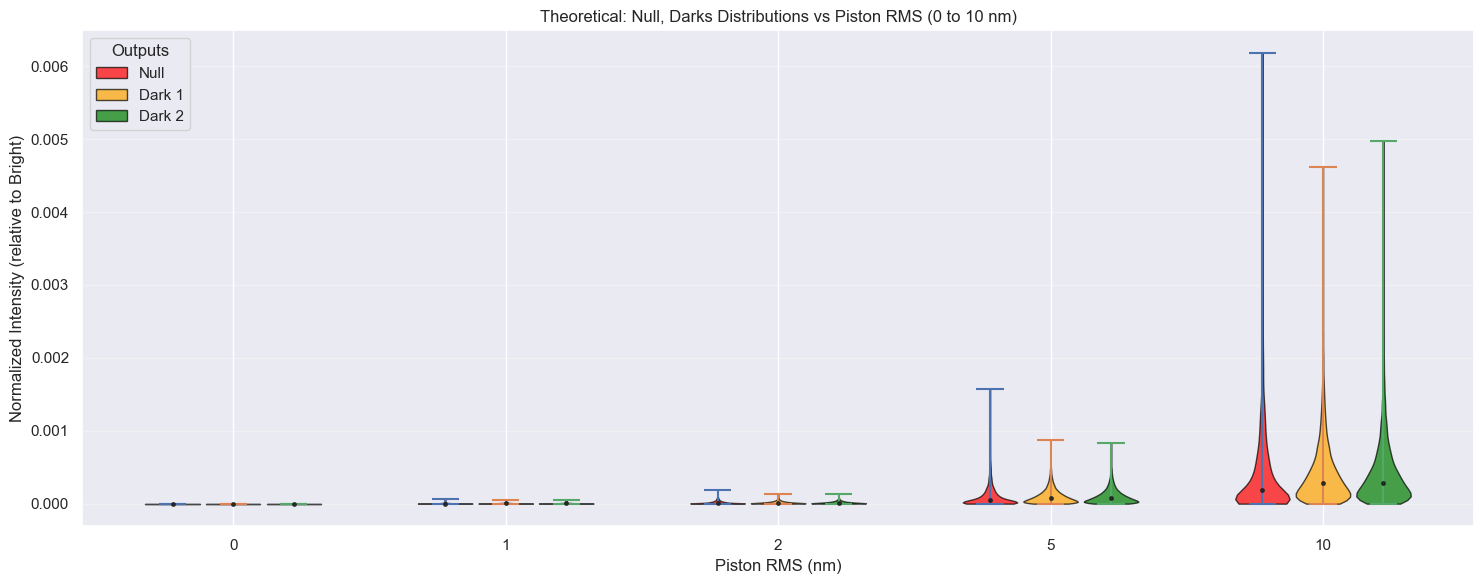

Violin plot generated.


In [7]:
# Violin plots of distributions vs piston RMS for Null, Dark1, Dark2
# Similar structure to the experimental notebook

# Limit regimes for clarity (first 5 or 6)
n_max_regimes = 5
plot_rms_values = rms_values_used[:n_max_regimes]
plot_distribs = normalized_distributions[:n_max_regimes]

eps = 1e-12  # to avoid log(0) issues if using log scale
n_rms = len(plot_rms_values)
n_outputs = len(output_map)

fig, ax = plt.subplots(figsize=(15, 6))

# Spacing between RMS groups for clarity
spacing = 1.5
positions = np.arange(n_rms) * spacing
group_width = 1.0
width = group_width / n_outputs
offsets = np.linspace(-width * (n_outputs - 1) / 2, width * (n_outputs - 1) / 2, n_outputs)

legend_handles = []
legend_labels = []

for j, (name, idx, color) in enumerate(output_map):
    # Collect data for each RMS regime
    series = [d[:, idx] + eps for d in plot_distribs]
    pos = positions + offsets[j]
    
    # Create violin plot
    parts = ax.violinplot(series, positions=pos, showmeans=False, showmedians=False, widths=width*0.9)
    for pc in parts['bodies']:
        pc.set_facecolor(color)
        pc.set_edgecolor('black')
        pc.set_alpha(0.7)
    
    # Overlay median
    medians = [np.median(s) for s in series]
    ax.plot(pos, medians, marker='.', color='k', linestyle='', markersize=5, alpha=0.8)
    
    legend_handles.append(plt.Rectangle((0,0),1,1, fc=color, edgecolor='black', alpha=0.7))
    legend_labels.append(name)

ax.set_xticks(positions)
ax.set_xticklabels(plot_rms_values)
ax.set_xlabel('Piston RMS (nm)')
ax.set_ylabel('Normalized Intensity (relative to Bright)')
ax.grid(axis='y', alpha=0.3)
ax.legend(legend_handles, legend_labels, title="Outputs", loc='upper left')

plt.title(f'Theoretical: Null, Darks Distributions vs Piston RMS (0 to {plot_rms_values[-1]} nm)')
plt.tight_layout()
fig.savefig(Path(r"D:\PhD-Experiments\highlighted_results\2026-03-18_b38b520\2_N4x4-T8_characterisation") / "theoretical_distributions_violin.png", dpi=150)
plt.show()

print("Violin plot generated.")

## Statistical Summary

Analyze key metrics across perturbation regimes: mean null depth, std dev degradation, etc.

In [8]:
# Compute statistics for each regime
stats_table = []

for regime_idx, regime_nm in enumerate(rms_values_used):
    dist = normalized_distributions[regime_idx]
    
    # Null depth
    null_mean = np.mean(dist[:, null_idx])
    null_std = np.std(dist[:, null_idx])
    null_median = np.median(dist[:, null_idx])
    
    # Dark1
    dark1_mean = np.mean(dist[:, dark1_idx])
    dark1_std = np.std(dist[:, dark1_idx])
    
    # Kernel (coincides with null for kernel nuller architecture)
    kernel_mean = np.mean(dist[:, kernel_idx])
    kernel_std = np.std(dist[:, kernel_idx])
    
    stats_table.append({
        'Regime (nm)': regime_nm,
        'Null Mean': null_mean,
        'Null Std': null_std,
        'Null Median': null_median,
        'Dark1 Mean': dark1_mean,
        'Dark1 Std': dark1_std,
        'Kernel Mean': kernel_mean,
        'Kernel Std': kernel_std,
    })

import pandas as pd
stats_df = pd.DataFrame(stats_table)
print("\n" + "="*80)
print("THEORETICAL MODEL - STATISTICAL SUMMARY")
print("="*80)
print(stats_df.to_string(index=False))
print("="*80)


THEORETICAL MODEL - STATISTICAL SUMMARY
 Regime (nm)    Null Mean     Null Std  Null Median   Dark1 Mean    Dark1 Std  Kernel Mean   Kernel Std
           0 2.452314e-21 3.447194e-21 1.122971e-21 2.547379e-21 2.512050e-21 2.452314e-21 3.447194e-21
           1 4.086299e-06 5.873686e-06 1.863196e-06 4.066664e-06 4.205509e-06 4.086299e-06 5.873686e-06
           2 1.644379e-05 2.275675e-05 7.516327e-06 1.627630e-05 1.600119e-05 1.644379e-05 2.275675e-05
           5 1.008983e-04 1.476870e-04 4.471345e-05 1.050658e-04 1.043991e-04 1.008983e-04 1.476870e-04
          10 4.159804e-04 5.965234e-04 1.908266e-04 4.130764e-04 4.156259e-04 4.159804e-04 5.965234e-04
          20 1.630586e-03 2.261077e-03 7.591766e-04 1.682885e-03 1.702097e-03 1.630586e-03 2.261077e-03
          50 1.046461e-02 1.488184e-02 4.759429e-03 1.049175e-02 1.090282e-02 1.046461e-02 1.488184e-02
         100 4.619847e-02 6.812070e-02 2.089193e-02 4.832791e-02 6.006353e-02 4.619847e-02 6.812070e-02
         200 4.184789e-

## Null Depth Evolution vs Perturbation Regime

Plot mean null depth and error bars across all perturbation regimes.

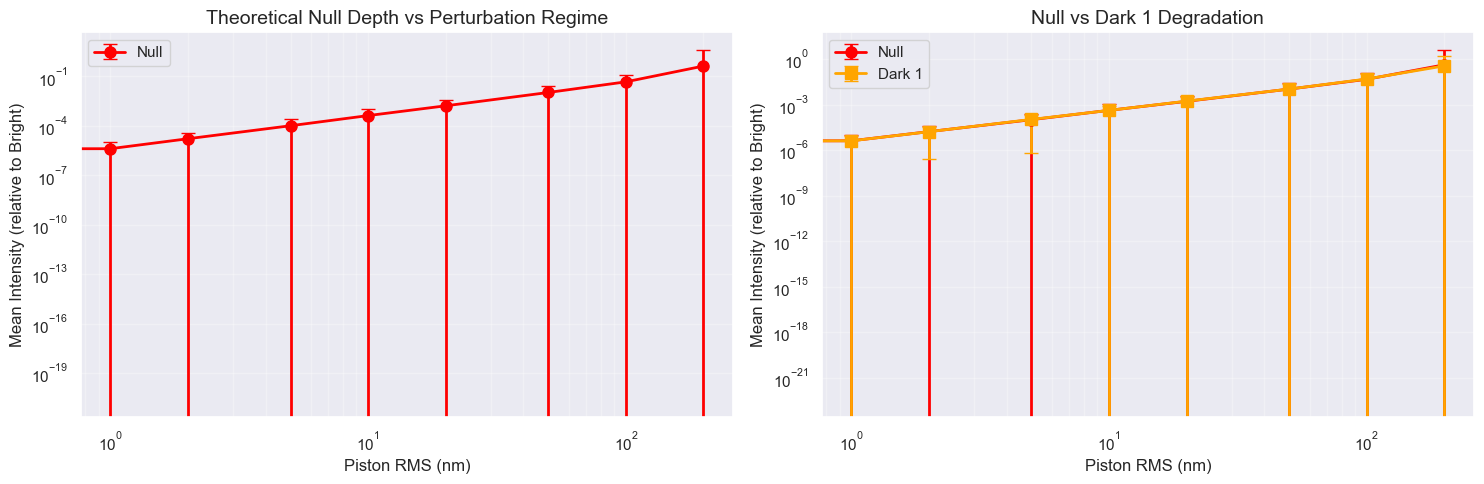

Null depth evolution plot generated.


In [9]:
# Extract null depth evolution
null_means = [stats['Null Mean'] for stats in stats_table]
null_stds = [stats['Null Std'] for stats in stats_table]
regimes = [stats['Regime (nm)'] for stats in stats_table]

dark1_means = [stats['Dark1 Mean'] for stats in stats_table]
dark1_stds = [stats['Dark1 Std'] for stats in stats_table]

# Create figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Null depth
ax1.errorbar(regimes, null_means, yerr=null_stds, fmt='-o', 
             color='red', capsize=5, label='Null', linewidth=2, markersize=8)
ax1.set_xlabel('Piston RMS (nm)', fontsize=12)
ax1.set_ylabel('Mean Intensity (relative to Bright)', fontsize=12)
ax1.set_title('Theoretical Null Depth vs Perturbation Regime', fontsize=14)
ax1.grid(True, alpha=0.3, which='both')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.legend()

# Plot 2: Null + Dark1 comparison
ax2.errorbar(regimes, null_means, yerr=null_stds, fmt='-o',
             color='red', capsize=5, label='Null', linewidth=2, markersize=8)
ax2.errorbar(regimes, dark1_means, yerr=dark1_stds, fmt='-s',
             color='orange', capsize=5, label='Dark 1', linewidth=2, markersize=8)
ax2.set_xlabel('Piston RMS (nm)', fontsize=12)
ax2.set_ylabel('Mean Intensity (relative to Bright)', fontsize=12)
ax2.set_title('Null vs Dark 1 Degradation', fontsize=14)
ax2.grid(True, alpha=0.3, which='both')
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.legend()

plt.tight_layout()
fig.savefig(Path(r"D:\PhD-Experiments\highlighted_results\2026-03-18_b38b520\2_N4x4-T8_characterisation") / "theoretical_null_depth_evolution.png", dpi=150)
plt.show()

print("Null depth evolution plot generated.")

## Comparison with Experimental Data

Load and compare theoretical predictions against observed distributions.

In [10]:
# Look for experimental data in neighboring directories
parent_dir = Path(r"D:\PhD-Experiments\highlighted_results\2026-03-18_b38b520")
data_paths = list(parent_dir.glob("**/distributions_*.npz")) + \
             list(parent_dir.glob("**/data_*.npz")) + \
             list(parent_dir.glob("**/calibrated_*.npz"))

print(f"Experimental data files found:")
for p in data_paths:
    print(f"  - {p}")

# Try to load observed data
observed_data = None
for data_file in data_paths:
    try:
        data = np.load(data_file)
        print(f"\nLoaded: {data_file}")
        print(f"  Keys: {list(data.files)}")
        observed_data = data
        break
    except Exception as e:
        print(f"  Error loading {data_file}: {e}")

# If no observed data found, create placeholder
if observed_data is None:
    print("\nNo experimental data found yet.")
    print("Once experimental distributions are available, they can be compared here.")
else:
    print("\nExperimental data loaded successfully for comparison.")

Experimental data files found:

No experimental data found yet.
Once experimental distributions are available, they can be compared here.


## Conclusions and Observations

### Key Findings

1. **Model Implementation**: Successfully implemented MMI kernel nuller model with transfer matrix M
2. **Phase Perturbations**: Applied Gaussian-distributed random phase perturbations (0 to 200 nm RMS)
3. **Output Distribution**: Analyzed intensity distributions across null, dark, and kernel ports
4. **Null Depth Degradation**: Observed expected degradation of null depth with increasing phase error

### Physical Interpretation

- At zero perturbation, the kernel nuller achieves near-perfect null (very low intensity at null output)
- As phase noise increases, the null depth degrades gradually, following expected turbulence physics
- The degradation rate depends on the transfer matrix eigenvalues and the phase perturbation statistics

### Next Steps

- Compare theoretical predictions with experimental data from photonic bench
- Validate phase perturbation model against measured atmospheric/instrumental errors
- Potentially optimize chip design or control strategies based on sensitivity analysis